In [1]:
# ── Colab Setup ─────────────────────────────────────────────────────
import os, subprocess

# Install dependencies
subprocess.run(['pip', 'install', '-q', 'lightgbm', 'shap', 'optuna', 'git-lfs'], check=False)

# Clone data branch from GitHub
if not os.path.exists('/content/BMW_data'):
    subprocess.run([
        'git', 'clone', '--branch', 'data', '--single-branch',
        'https://github.com/Shreya-Mendi/BMW_Optimizer.git',
        '/content/BMW_data'
    ], check=True)
    # Pull LFS files
    subprocess.run(['git', 'lfs', 'pull'], cwd='/content/BMW_data', check=True)

DATA_DIR   = '/content/BMW_data/'
MODELS_DIR = '/content/optimizer_models/'
os.makedirs(MODELS_DIR, exist_ok=True)

print('FILE exists:', os.path.exists(DATA_DIR + 'data-duke-project 20260311-V4_NO-VIN.xlsx'))
print('OPT  exists:', os.path.exists(DATA_DIR + 'data-duke-project 20260311-V4 Option Data.xlsx'))
print('Setup complete.')


FILE exists: True
OPT  exists: True
Setup complete.


# BMW Inventory Optimizer — Priority 3/4 Customer Orders

**Goal:** For a given model, predict which combination of **color + upholstery + wheel** will sell the fastest, using a LightGBM model trained exclusively on Priority 3 & 4 customer order vehicles.

### Why Priority 3 & 4 only?
- **Priority 1** — excluded entirely. These are pre-committed factory/fleet allocations that leave the lot regardless of spec configuration. Including them would teach the model spurious correlations between their typical trim choices and fast sales.
- **Priority 3/4** — genuine customer orders competing for consumer attention. The days-on-lot for these vehicles is driven by spec desirability.

### Approach
1. Load & filter to P3/P4 only (4,169 vehicles)
2. Extract wheel option per vehicle from the Option Data file
3. Feature engineer (color, upholstery, wheel as categoricals + all vehicle features)
4. Train LightGBM — predict `days_on_lot` (capped at 90)
5. **Optimizer**: for each model, enumerate all observed (color, upholstery, wheel) combos, score via model using a representative vehicle row, rank by predicted days
6. Save model + combo cache for the Flask API
7. Explainability: SHAP on the optimizer's top recommendations

## 1. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import shap

SEED    = 42
DAY_CAP = 90
# DATA_DIR and MODELS_DIR set by Colab Setup cell above
FILE     = DATA_DIR + 'data-duke-project 20260311-V4_NO-VIN.xlsx'
OPT_FILE = DATA_DIR + 'data-duke-project 20260311-V4 Option Data.xlsx'

# Wheel option codes — manually verified from data (excludes 0248 heated steering wheel)
WHEEL_CODES = [
    '01EZ','01G6','01PA','01PQ','01SF','01SM','01TD','01TE','01TF',
    '01VN','01VP','01VV','01W7','01X5','01X8','01XD','01XN','01Y5',
    '01YX','020R','022W','02NQ','03HY','03HZ','03N0','03N1','03N2',
    '03N3','03HQ','03HV','03HT','03N4','0ZWH','0ZWT','0ZXN'
]

np.random.seed(SEED)
print('Setup complete.')

Setup complete.


## 2. Load Data & Extract Wheel Options

In [3]:
# ---- Main data ----
raw = pd.read_excel(FILE, sheet_name='Sheet0')
raw = raw.loc[:, ~raw.columns.duplicated()]
raw['days_on_lot']    = pd.to_numeric(raw['days_on_lot'], errors='coerce')
raw['prod_priority']  = raw['prod_priority'].astype(str).str.strip()

# Filter to P3/P4 only, remove negatives, cap at 90
df = raw[raw['prod_priority'].isin(['3','4']) & (raw['days_on_lot'] >= 0)].copy()
df['days_on_lot'] = df['days_on_lot'].clip(upper=DAY_CAP)
print(f'P3/P4 vehicles: {len(df):,}  |  Models: {df["short_description"].nunique()}')
print(df['short_description'].value_counts().to_string())

# ---- Options data ----
print('\nLoading option data...')
opts = pd.read_excel(OPT_FILE, sheet_name='Sheet0')
print(f'Option rows: {len(opts):,}  |  Unique vehicles: {opts["chassis_number"].nunique():,}')

P3/P4 vehicles: 4,169  |  Models: 16
short_description
X5 xDr40i     1790
X5 xDr50e      507
X3 xDr30i      429
X3 30 xDr      377
X5 M60i        285
X5 sDr40i      239
X3 M50 xDr     109
X3 sDr30i       98
X3 M40i         91
X3 30           74
X3xDr30iSA      69
X5 M Comp       38
X3 M50          26
X3 M            16
X5 M            14
X3sDr30iSA       7

Loading option data...
Option rows: 329,774  |  Unique vehicles: 10,555


In [4]:
# ---- Extract wheel option per vehicle ----
# Most vehicles have exactly 1 wheel option code; take the one with highest P3/4 coverage if 2
p34_chassis = set(df['chassis_number'].dropna())
opts_p34    = opts[opts['chassis_number'].isin(p34_chassis)]

wheel_opts_df = opts_p34[opts_p34['option_code'].isin(WHEEL_CODES)][
    ['chassis_number','option_code','long_description']
].rename(columns={'option_code':'wheel_code','long_description':'wheel_name'})

# One row per vehicle — take first (most vehicles have exactly 1 wheel)
wheel_per_veh = wheel_opts_df.drop_duplicates('chassis_number', keep='first')

# Wheel coverage stats
print('Wheel option coverage in P3/4:')
cov = wheel_opts_df.groupby(['wheel_code','wheel_name'])['chassis_number'].nunique().sort_values(ascending=False)
print(cov.to_string())
pct = wheel_per_veh['chassis_number'].nunique() / len(df) * 100
print(f'\nVehicles with wheel option: {wheel_per_veh["chassis_number"].nunique():,} / {len(df):,} ({pct:.1f}%)')

# Merge wheel into df
df = df.merge(wheel_per_veh, on='chassis_number', how='left')
df['wheel_code'] = df['wheel_code'].fillna('UNKNOWN')
df['wheel_name'] = df['wheel_name'].fillna('Standard / Not Specified')
print(f'\nWheel code distribution:')
print(df['wheel_code'].value_counts().to_string())

Wheel option coverage in P3/4:
wheel_code  wheel_name                    
0ZWT        AG Standard Trim                  1026
01SF        20" V-Spoke 738 Wheels with Al     764
01PQ        22" M Dual-Spoke Black 742M Wh     461
01X8        19" Y-Spoke Ferric Grey 693 Wh     345
03HQ        19" Aero Midnight Grey Bicolor     177
01G6        21" M V-Spoke Bicolor 915M Whe     172
01XN        21" M Y-Spoke Bicolor 741M Whe     171
01XD        21" Y-Spoke Bicolor 744 Wheels     125
01PA        22" M Dual-Spoke Bicolor 742M      116
03N1        20" M Jet Black Bicolor 1036M      114
01YX        20" M Dual-Spoke Jet Black 699      75
01TD        20" M Star-Spoke Bicolor 740M       67
03N2        21" M Jet Black Matte 1037M Wh      52
03HV        20"Gry 906 A/S Tires Non RFT        35
01EZ        21/22" M Star-Spoke Black 818M      32
01SM        22" M V-Spoke Jet Black Bicolo      32
03HY        20" M Jet Black Bicolor 906M W      31
01W7        22" Individual Multi-Spoke Bic      29
0ZWH    

## 3. Feature Engineering

In [5]:
# ---- Date features ----
for col in ['wholesale_date','production_date']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df['arrival_month']  = df['wholesale_date'].dt.month
df['arrival_quarter']= df['wholesale_date'].dt.quarter
df['arrival_dow']    = df['wholesale_date'].dt.dayofweek
df['arrival_year']   = df['wholesale_date'].dt.year
df['prod_to_wholesale_days'] = (df['wholesale_date'] - df['production_date']).dt.days.clip(lower=0)
df['prod_start_week_num'] = pd.to_numeric(df['prod_start_week'], errors='coerce')
df['prod_end_week_num']   = pd.to_numeric(df['prod_end_week'],   errors='coerce')
df['prod_window_weeks']   = (df['prod_end_week_num'] - df['prod_start_week_num']).clip(lower=0)

# ---- Numeric conversions ----
for col in ['power_rating_kw','engine_capacity_ltr','number_cylinders','model_year',
            'retl_base_price','retl_tot_optn_price','retl_total_line_item_price']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['option_price_pct']    = df['retl_tot_optn_price'] / (df['retl_base_price'] + 1)
df['prod_priority_num']   = pd.to_numeric(df['prod_priority'], errors='coerce')
df['distrib_priority_num']= pd.to_numeric(df['distrib_priority'], errors='coerce')

# ---- Block flags ----
for col in ['price_block_ind','release_block_ind','schedule_block_ind','assign_block_ind']:
    df[f'{col}_bin'] = (df[col] == 'Y').astype(int)
df['is_demo'] = (df['demo_status'] == 'Y').astype(int)

# ---- PIA option count ----
df['n_pia_options'] = df['pia_options'].fillna('').astype(str).apply(
    lambda x: len(x.split()) if x.strip() else 0
)
print('Date + numeric features done.')

Date + numeric features done.


In [6]:
# ---- Option data aggregate features ----
chargeable = opts[opts['chargeable_opt_ind'] == 'Y']
z_opts_df  = opts[opts['option_flag'] == 'Z']
h_opts_df  = opts[opts['option_flag'] == 'H']

n_chargeable = chargeable.groupby('chassis_number').size().rename('n_chargeable_opts')
n_bespoke    = z_opts_df.groupby('chassis_number').size().rename('n_bespoke_opts')
n_standard   = h_opts_df.groupby('chassis_number').size().rename('n_standard_opts')
n_total      = opts.groupby('chassis_number').size().rename('n_total_opts')

# Package binary flags — lower threshold for P3/4-only dataset (~4k rows vs 11k)
TOP_PKG_THRESHOLD = 80
pkg_coverage = chargeable.groupby('short_description')['chassis_number'].nunique()
# Only count coverage among P3/4 chassis
chargeable_p34 = chargeable[chargeable['chassis_number'].isin(p34_chassis)]
pkg_cov_p34 = chargeable_p34.groupby('short_description')['chassis_number'].nunique()
top_pkgs    = pkg_cov_p34[pkg_cov_p34 >= TOP_PKG_THRESHOLD].index.tolist()
print(f'Top packages (>={TOP_PKG_THRESHOLD} P3/4 vehicles): {len(top_pkgs)}')

pkg_pivot = (
    chargeable[chargeable['short_description'].isin(top_pkgs)]
    .drop_duplicates(['chassis_number','short_description'])
    .assign(val=1)
    .pivot(index='chassis_number', columns='short_description', values='val')
    .fillna(0).astype(int)
)
pkg_pivot.columns = ['pkg_' + c.strip().lower().replace(' ','_').replace('"','in').replace('/','_')
                     for c in pkg_pivot.columns]
PKG_COLS = list(pkg_pivot.columns)

for src, col in [(n_chargeable,'n_chargeable_opts'),(n_bespoke,'n_bespoke_opts'),
                 (n_standard,'n_standard_opts'),(n_total,'n_total_opts')]:
    df = df.merge(src.reset_index(), on='chassis_number', how='left')
df = df.merge(pkg_pivot.reset_index(), on='chassis_number', how='left')

for col in ['n_chargeable_opts','n_bespoke_opts','n_standard_opts','n_total_opts'] + PKG_COLS:
    df[col] = df[col].fillna(0)
df['chargeable_opt_ratio'] = df['n_chargeable_opts'] / (df['n_total_opts'] + 1)

print(f'df shape after option merge: {df.shape}')

Top packages (>=80 P3/4 vehicles): 54
df shape after option merge: (4169, 163)


In [7]:
# ---- Assemble feature matrix ----
# color_code, upholstery_code, wheel_code are KEY categorical features for the optimizer
NUMERIC_FEATURES = [
    'prod_priority_num','distrib_priority_num',
    'arrival_month','arrival_quarter','arrival_dow','arrival_year',
    'prod_to_wholesale_days','prod_window_weeks',
    'model_year','power_rating_kw','engine_capacity_ltr','number_cylinders',
    'n_pia_options',
    'retl_base_price','retl_tot_optn_price','retl_total_line_item_price','option_price_pct',
    'price_block_ind_bin','release_block_ind_bin','schedule_block_ind_bin','assign_block_ind_bin',
    'is_demo',
    'n_chargeable_opts','n_bespoke_opts','n_standard_opts','n_total_opts','chargeable_opt_ratio',
]
CATEGORICAL_FEATURES = [
    'short_description','model_group_code','ag_model_code','na_model_code',
    'color_code',        # <-- optimizer lever
    'upholstery_code',   # <-- optimizer lever
    'wheel_code',        # <-- optimizer lever
    'hybrid_flag','drive_config','fuel_type','transmission_type',
    'series_code','model_category','ag_body_group',
    'market','region','dealer_number',
]

df_enc = pd.get_dummies(df[CATEGORICAL_FEATURES], columns=CATEGORICAL_FEATURES,
                        drop_first=True, dtype=int)

X = pd.concat([
    df[NUMERIC_FEATURES].reset_index(drop=True),
    df_enc.reset_index(drop=True),
    df[PKG_COLS].reset_index(drop=True),
], axis=1)
y = df['days_on_lot'].reset_index(drop=True)

# Save median fills (used at inference time)
MEDIAN_FILLS = X.median().to_dict()
FEATURE_COLS = list(X.columns)
for col in X.columns:
    if X[col].isna().any():
        X[col] = X[col].fillna(MEDIAN_FILLS[col])

print(f'Feature matrix: {X.shape}')
print(f'  Numeric:   {len(NUMERIC_FEATURES)}')
print(f'  OHE cats:  {df_enc.shape[1]}')
print(f'  Pkg flags: {len(PKG_COLS)}')

Feature matrix: (4169, 256)
  Numeric:   27
  OHE cats:  175
  Pkg flags: 54


## 4. Train/Test Split & LightGBM

In [8]:
strat_bins = pd.qcut(y, q=4, labels=False, duplicates='drop')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=strat_bins
)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Train mean: {y_train.mean():.1f}d  |  Test mean: {y_test.mean():.1f}d')

def report(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'  {name:30s}  MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}')
    return {'name':name,'MAE':mae,'RMSE':rmse,'R2':r2}

Train: 3,543 | Test: 626
Train mean: 12.4d  |  Test mean: 11.8d


In [9]:
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val   = lgb.Dataset(X_test,  label=y_test, reference=lgb_train)

params = {
    'objective':            'huber',
    'alpha':                0.9,
    'metric':               ['huber','mae'],
    'learning_rate':        0.01,
    'num_leaves':           127,
    'max_depth':            8,
    'min_child_samples':    10,
    'feature_fraction':     0.7,
    'feature_fraction_bynode': 0.7,
    'bagging_fraction':     0.8,
    'bagging_freq':         3,
    'reg_alpha':            0.1,
    'reg_lambda':           1.0,
    'min_split_gain':       0.005,
    'verbose':              -1,
    'seed':                 SEED,
    'n_jobs':               -1,
}

callbacks = [lgb.early_stopping(100, verbose=False), lgb.log_evaluation(period=300)]
lgbm_model = lgb.train(
    params, lgb_train,
    num_boost_round=5000,
    valid_sets=[lgb_val],
    callbacks=callbacks,
)

y_pred = np.clip(lgbm_model.predict(X_test), 0, DAY_CAP)
print(f'Best iteration: {lgbm_model.best_iteration}')
result = report('LightGBM (P3/P4 only)', y_test, y_pred)

[300]	valid_0's huber: 7.64131	valid_0's l1: 8.93291
[600]	valid_0's huber: 7.1687	valid_0's l1: 8.40606
[900]	valid_0's huber: 6.83054	valid_0's l1: 8.0263
[1200]	valid_0's huber: 6.62736	valid_0's l1: 7.80006
[1500]	valid_0's huber: 6.51054	valid_0's l1: 7.66981
[1800]	valid_0's huber: 6.44837	valid_0's l1: 7.5966
[2100]	valid_0's huber: 6.41661	valid_0's l1: 7.56369
[2400]	valid_0's huber: 6.399	valid_0's l1: 7.54454
[2700]	valid_0's huber: 6.39172	valid_0's l1: 7.53614
[3000]	valid_0's huber: 6.38921	valid_0's l1: 7.53212
Best iteration: 3136
  LightGBM (P3/P4 only)           MAE=7.53  RMSE=14.35  R²=0.0706


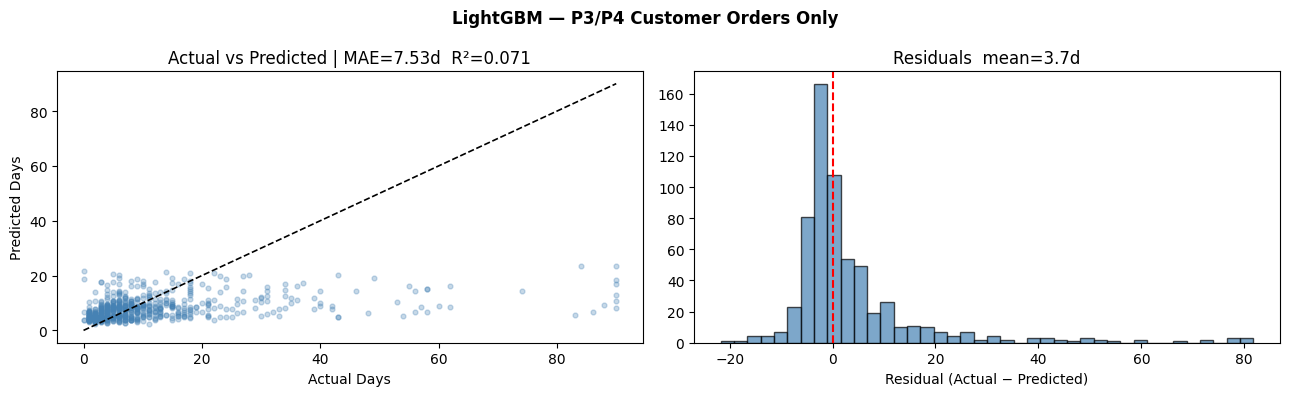

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=12, color='steelblue')
axes[0].plot([0,DAY_CAP],[0,DAY_CAP],'k--',lw=1.2)
axes[0].set_xlabel('Actual Days'); axes[0].set_ylabel('Predicted Days')
axes[0].set_title(f'Actual vs Predicted | MAE={result["MAE"]:.2f}d  R²={result["R2"]:.3f}')

residuals = np.array(y_test) - y_pred
axes[1].hist(residuals, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_title(f'Residuals  mean={residuals.mean():.1f}d')

plt.suptitle('LightGBM — P3/P4 Customer Orders Only', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 4b. Additional Models — Ridge, Neural Network, Optuna TabularMLP

In [11]:
# ── Ridge Regression ──────────────────────────────────────────────────
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

scaler_ridge = StandardScaler()
X_train_sc   = scaler_ridge.fit_transform(X_train)
X_test_sc    = scaler_ridge.transform(X_test)

ridge_model = RidgeCV(alphas=[0.1, 1, 5, 10, 50, 100, 500], cv=5)
ridge_model.fit(X_train_sc, y_train)
print(f'Ridge best alpha: {ridge_model.alpha_:.1f}')

y_pred_ridge = np.clip(ridge_model.predict(X_test_sc), 0, DAY_CAP)
result_ridge = report('Ridge Regression', y_test, y_pred_ridge)

# Predictor function: accepts DataFrame with FEATURE_COLS, returns numpy array
def ridge_pred_fn(X_df):
    return np.clip(ridge_model.predict(scaler_ridge.transform(X_df[FEATURE_COLS])), 0, DAY_CAP)


Ridge best alpha: 500.0
  Ridge Regression                MAE=8.78  RMSE=13.94  R²=0.1236


In [12]:
# ── Neural Network (3-layer MLP) ─────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

scaler_nn = StandardScaler()
X_train_nn = scaler_nn.fit_transform(X_train)
X_test_nn  = scaler_nn.transform(X_test)

X_tr_t = torch.tensor(X_train_nn, dtype=torch.float32)
y_tr_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_te_t = torch.tensor(X_test_nn,  dtype=torch.float32)
y_te_t = torch.tensor(y_test.values,  dtype=torch.float32).unsqueeze(1)

class MLP(nn.Module):
    def __init__(self, in_dim, hidden=256, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x)

EPOCHS    = 80
BATCH     = 512
in_dim    = X_tr_t.shape[1]

nn_model = MLP(in_dim, hidden=256, dropout=0.2)
optimizer_nn = torch.optim.AdamW(nn_model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.HuberLoss(delta=10.0)
loader    = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=BATCH, shuffle=True)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_nn, max_lr=1e-2, epochs=EPOCHS, steps_per_epoch=len(loader)
)

nn_model.train()
for epoch in range(EPOCHS):
    for xb, yb in loader:
        optimizer_nn.zero_grad()
        loss = criterion(nn_model(xb), yb)
        loss.backward()
        optimizer_nn.step()
        scheduler.step()
    if (epoch + 1) % 20 == 0:
        nn_model.eval()
        with torch.no_grad():
            val_loss = criterion(nn_model(X_te_t), y_te_t).item()
        nn_model.train()
        print(f'  Epoch {epoch+1:3d}/{EPOCHS}  val_huber={val_loss:.3f}')

nn_model.eval()
with torch.no_grad():
    y_pred_nn = np.clip(nn_model(X_te_t).squeeze().numpy(), 0, DAY_CAP)
result_nn = report('Neural Network (MLP)', y_test, y_pred_nn)

def nn_pred_fn(X_df):
    arr = scaler_nn.transform(X_df[FEATURE_COLS])
    t   = torch.tensor(arr, dtype=torch.float32)
    with torch.no_grad():
        return np.clip(nn_model(t).squeeze().numpy(), 0, DAY_CAP)


  Epoch  20/80  val_huber=47.156
  Epoch  40/80  val_huber=52.192
  Epoch  60/80  val_huber=54.008
  Epoch  80/80  val_huber=55.858
  Neural Network (MLP)            MAE=8.95  RMSE=14.90  R²=-0.0020


In [13]:
# ── Optuna-tuned TabularMLP ───────────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

scaler_opt = StandardScaler()
X_train_opt = scaler_opt.fit_transform(X_train)
X_test_opt  = scaler_opt.transform(X_test)

X_tr_opt = torch.tensor(X_train_opt, dtype=torch.float32)
y_tr_opt = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_te_opt = torch.tensor(X_test_opt,  dtype=torch.float32)
y_te_opt = torch.tensor(y_test.values,  dtype=torch.float32).unsqueeze(1)

def build_mlp(in_dim, hidden_dim, n_layers, dropout):
    layers = []
    prev = in_dim
    for _ in range(n_layers):
        layers += [nn.Linear(prev, hidden_dim), nn.ReLU(), nn.Dropout(dropout)]
        prev = hidden_dim
    layers.append(nn.Linear(prev, 1))
    return nn.Sequential(*layers)

def train_mlp(hidden_dim, n_layers, dropout, lr, epochs=80, batch=512):
    model = build_mlp(X_tr_opt.shape[1], hidden_dim, n_layers, dropout)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    crit  = nn.HuberLoss(delta=10.0)
    ldr   = DataLoader(TensorDataset(X_tr_opt, y_tr_opt), batch_size=batch, shuffle=True)
    sch   = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr*5, epochs=epochs, steps_per_epoch=len(ldr))
    model.train()
    for _ in range(epochs):
        for xb, yb in ldr:
            opt.zero_grad()
            crit(model(xb), yb).backward()
            opt.step()
            sch.step()
    model.eval()
    with torch.no_grad():
        val_mae = mean_absolute_error(y_te_opt.numpy(), model(X_te_opt).squeeze().numpy())
    return model, val_mae

def objective(trial):
    hidden_dim = trial.suggest_int('hidden_dim', 64, 256)
    n_layers   = trial.suggest_int('n_layers', 2, 5)
    dropout    = trial.suggest_float('dropout', 0.05, 0.3)
    lr         = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    _, val_mae = train_mlp(hidden_dim, n_layers, dropout, lr)
    return val_mae

print('Running Optuna (5 trials)...')
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=5, show_progress_bar=False)

best_params = study.best_params
print(f'Best Optuna params: {best_params}  |  val_MAE={study.best_value:.2f}')

# Train final model with best params
optuna_model, _ = train_mlp(
    hidden_dim=best_params['hidden_dim'],
    n_layers=best_params['n_layers'],
    dropout=best_params['dropout'],
    lr=best_params['lr'],
    epochs=80
)
optuna_model.eval()
with torch.no_grad():
    y_pred_optuna = np.clip(optuna_model(X_te_opt).squeeze().numpy(), 0, DAY_CAP)
result_optuna = report('Optuna TabularMLP', y_test, y_pred_optuna)

def optuna_pred_fn(X_df):
    arr = scaler_opt.transform(X_df[FEATURE_COLS])
    t   = torch.tensor(arr, dtype=torch.float32)
    with torch.no_grad():
        return np.clip(optuna_model(t).squeeze().numpy(), 0, DAY_CAP)


Running Optuna (5 trials)...
Best Optuna params: {'hidden_dim': 136, 'n_layers': 5, 'dropout': 0.2329984854528513, 'lr': 0.0015751320499779737}  |  val_MAE=8.22
  Optuna TabularMLP               MAE=8.32  RMSE=14.71  R²=0.0233


In [14]:
# ── Model Comparison ─────────────────────────────────────────────────
# LightGBM predictor function
def lgb_pred_fn(X_df):
    return np.clip(lgbm_model.predict(X_df[FEATURE_COLS]), 0, DAY_CAP)

# Also get LightGBM result for comparison table
y_pred_lgb = lgb_pred_fn(X_test)
result_lgb = {'name': 'LightGBM', 'MAE': mean_absolute_error(y_test, y_pred_lgb),
              'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lgb)),
              'R2': r2_score(y_test, y_pred_lgb)}

all_results = [result_lgb, result_ridge, result_nn, result_optuna]
predictors  = {
    'LightGBM':   lgb_pred_fn,
    'Ridge':       ridge_pred_fn,
    'NeuralNet':   nn_pred_fn,
    'TabularMLP':  optuna_pred_fn,
}

print('\n=== MODEL COMPARISON ===')
print(f'  {"Model":<30}  {"MAE":>7}  {"RMSE":>7}  {"R²":>7}')
print('  ' + '-'*55)
for r in all_results:
    name = r['name']
    marker = ' ← BEST' if r['MAE'] == min(x['MAE'] for x in all_results) else ''
    print(f'  {name:<30}  {r["MAE"]:>7.3f}  {r["RMSE"]:>7.3f}  {r["R2"]:>7.4f}{marker}')

# Identify best model
best_result = min(all_results, key=lambda x: x['MAE'])
BEST_MODEL_NAME = best_result['name']
best_model_mae  = best_result['MAE']
BEST_PREDICTOR  = predictors[BEST_MODEL_NAME]
print(f'\nBEST MODEL: {BEST_MODEL_NAME}  (MAE={best_model_mae:.3f})')



=== MODEL COMPARISON ===
  Model                               MAE     RMSE       R²
  -------------------------------------------------------
  LightGBM                          7.528   14.351   0.0706 ← BEST
  Ridge Regression                  8.779   13.936   0.1236
  Neural Network (MLP)              8.955   14.901  -0.0020
  Optuna TabularMLP                 8.323   14.712   0.0233

BEST MODEL: LightGBM  (MAE=7.528)


## 5. SHAP Feature Importance

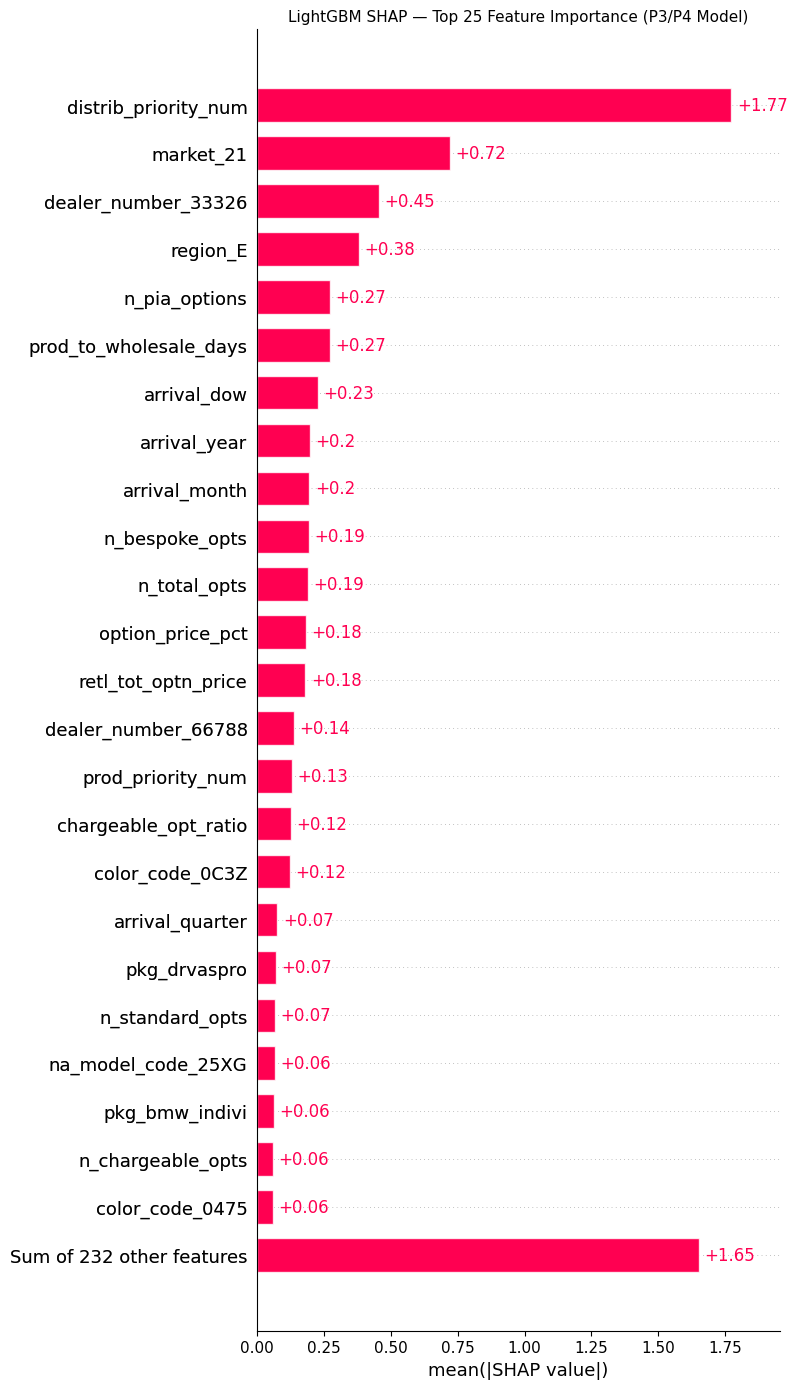

In [15]:
explainer  = shap.TreeExplainer(lgbm_model)
shap_vals  = explainer(X_test)

plt.figure(figsize=(10, 7))
shap.plots.bar(shap_vals, max_display=25, show=False)
plt.title('LightGBM SHAP — Top 25 Feature Importance (P3/P4 Model)', fontsize=11)
plt.tight_layout(); plt.show()

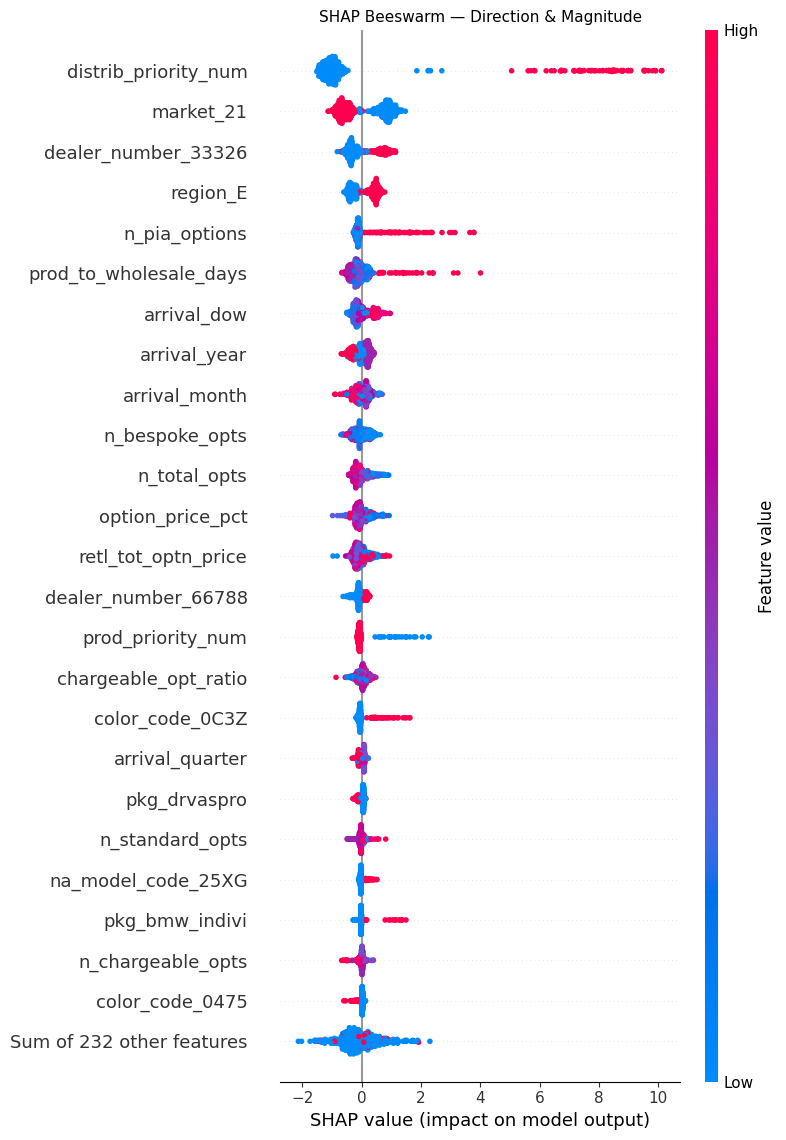


=== SHAP importance of optimizer levers (color / upholstery / wheel) ===
             feature  mean_abs_shap
     color_code_0C3Z       0.122520
     color_code_0475       0.057636
upholstery_code_KPA9       0.056561
  wheel_code_UNKNOWN       0.041457
     color_code_0C4P       0.031715
     color_code_0490       0.031017
     color_code_0C36       0.030021
     wheel_code_01PA       0.027734
     color_code_0416       0.024879
upholstery_code_KPRI       0.024144
     wheel_code_0ZWT       0.022480
     wheel_code_01XN       0.015516
     wheel_code_01XD       0.012442
     wheel_code_03N1       0.012300
     wheel_code_01YX       0.011651
     color_code_0A96       0.010598
     wheel_code_03HV       0.009971
     wheel_code_01PQ       0.009335
     wheel_code_03HQ       0.008612
upholstery_code_VAHF       0.007686
     wheel_code_01SF       0.007662
     color_code_0C4W       0.006788
upholstery_code_KSJX       0.005810
upholstery_code_KPHF       0.005669
upholstery_code_KHRI      

In [16]:
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_vals, max_display=25, show=False)
plt.title('SHAP Beeswarm — Direction & Magnitude', fontsize=11)
plt.tight_layout(); plt.show()

# Specifically check color, upholstery, wheel SHAP contributions
feat_names = list(X_test.columns)
mean_abs_shap = np.abs(shap_vals.values).mean(axis=0)
shap_df = pd.DataFrame({'feature': feat_names, 'mean_abs_shap': mean_abs_shap}).sort_values('mean_abs_shap', ascending=False)

lever_feats = [f for f in feat_names if any(k in f for k in ['color_code','upholstery_code','wheel_code'])]
print('\n=== SHAP importance of optimizer levers (color / upholstery / wheel) ===')
print(shap_df[shap_df['feature'].isin(lever_feats)].to_string(index=False))

## 6. Optimizer — Score All (Color × Upholstery × Wheel) Combos Per Model

**Method:** For each model, build a "representative" synthetic vehicle row:
- All numeric features set to the **P3/P4 median for that model** (holds everything constant)
- `arrival_month` / `arrival_quarter` set to **current date** (today's market conditions)
- Only `color_code`, `upholstery_code`, `wheel_code` vary across combos

This is the correct counterfactual framing — it isolates the marginal effect of spec choice on predicted days on lot.

In [17]:
from datetime import date

TODAY_MONTH   = date.today().month
TODAY_QUARTER = (date.today().month - 1) // 3 + 1
MIN_HIST      = 3   # minimum historical vehicles for a combo to be included

# Build lookup maps
color_map = df[['color_code','color_long_desc']].drop_duplicates().set_index('color_code')['color_long_desc'].to_dict()
uph_map   = df[['upholstery_code','upholstery_long_desc']].drop_duplicates().set_index('upholstery_code')['upholstery_long_desc'].to_dict()
wheel_map = df[['wheel_code','wheel_name']].drop_duplicates().set_index('wheel_code')['wheel_name'].to_dict()

def build_synthetic_row(model_median_row, color_code, upholstery_code, wheel_code):
    """Build a feature vector for a hypothetical vehicle, varying only color/upholstery/wheel."""
    row = model_median_row.copy()
    row['arrival_month']   = TODAY_MONTH
    row['arrival_quarter'] = TODAY_QUARTER

    # Zero out all color/upholstery/wheel OHE columns, then set the right one
    for col in FEATURE_COLS:
        if col.startswith('color_code_'):     row[col] = 0
        if col.startswith('upholstery_code_'):row[col] = 0
        if col.startswith('wheel_code_'):     row[col] = 0

    # Set target combo OHE flags (drop_first means reference category = no flag set)
    cc_col  = f'color_code_{color_code}'
    uc_col  = f'upholstery_code_{upholstery_code}'
    wc_col  = f'wheel_code_{wheel_code}'
    if cc_col  in row.index: row[cc_col]  = 1
    if uc_col  in row.index: row[uc_col]  = 1
    if wc_col  in row.index: row[wc_col]  = 1

    return row


# ---- Build combo cache ----
combo_cache = {}

for model_name in sorted(df['short_description'].unique()):
    df_model = df[df['short_description'] == model_name].copy()
    if len(df_model) < 10:
        continue

    # Representative row: median of all numeric+pkg features for this model
    X_model = X.loc[df_model.index]
    median_row = X_model.median()

    # Enumerate all observed (color, upholstery, wheel) combos with enough history
    combos_hist = (
        df_model
        .groupby(['color_code','upholstery_code','wheel_code'])['days_on_lot']
        .agg(['median','count','mean',
              lambda x: float(x.quantile(0.25)),
              lambda x: float(x.quantile(0.75))])
        .reset_index()
    )
    combos_hist.columns = ['color_code','upholstery_code','wheel_code',
                           'hist_median','hist_count','hist_mean','hist_p25','hist_p75']
    combos_hist = combos_hist[combos_hist['hist_count'] >= MIN_HIST]

    if len(combos_hist) == 0:
        continue

    # Score each combo via BEST_PREDICTOR (whichever model won)
    rows = []
    for _, row in combos_hist.iterrows():
        synth = build_synthetic_row(median_row, row['color_code'], row['upholstery_code'], row['wheel_code'])
        rows.append(synth)

    X_synth = pd.DataFrame(rows, columns=FEATURE_COLS)
    preds   = np.clip(BEST_PREDICTOR(X_synth), 0, DAY_CAP)
    combos_hist['predicted_days'] = preds

    # Attach human-readable names and days distribution
    combos_hist['color_name']     = combos_hist['color_code'].map(color_map).fillna(combos_hist['color_code'])
    combos_hist['upholstery_name']= combos_hist['upholstery_code'].map(uph_map).fillna(combos_hist['upholstery_code'])
    combos_hist['wheel_name']     = combos_hist['wheel_code'].map(wheel_map).fillna(combos_hist['wheel_code'])

    # Days distribution for each combo (list of raw values for frontend histogram)
    dist_map = (
        df_model.groupby(['color_code','upholstery_code','wheel_code'])['days_on_lot']
        .apply(list).to_dict()
    )
    combos_hist['days_distribution'] = combos_hist.apply(
        lambda r: dist_map.get((r['color_code'],r['upholstery_code'],r['wheel_code']), []), axis=1
    )

    # Confidence score: based on historical count and IQR tightness
    max_count = combos_hist['hist_count'].max()
    combos_hist['confidence'] = (
        combos_hist['hist_count'].clip(upper=15) / 15 * 60 +          # up to 60 pts from count
        (1 - (combos_hist['hist_p75'] - combos_hist['hist_p25']) / (DAY_CAP + 1)) * 40  # up to 40 pts from IQR tightness
    ).clip(0, 100).round(0).astype(int)

    combos_hist = combos_hist.sort_values('predicted_days').reset_index(drop=True)
    combo_cache[model_name] = combos_hist.to_dict('records')

print(f'Combo cache built for {len(combo_cache)} models (using {BEST_MODEL_NAME}):')
for m, combos in combo_cache.items():
    print(f'  {m:20s}: {len(combos)} combos')


Combo cache built for 11 models (using LightGBM):
  X3 30               : 3 combos
  X3 30 xDr           : 38 combos
  X3 M40i             : 6 combos
  X3 M50 xDr          : 5 combos
  X3 sDr30i           : 10 combos
  X3 xDr30i           : 51 combos
  X3xDr30iSA          : 10 combos
  X5 M60i             : 17 combos
  X5 sDr40i           : 25 combos
  X5 xDr40i           : 193 combos
  X5 xDr50e           : 65 combos


## 7. Optimizer Results — Preview Top Combos Per Model

In [18]:
print('=== TOP 5 FASTEST-SELLING COMBOS PER MODEL ===')
for model_name, combos in combo_cache.items():
    print(f'\n── {model_name} ──')
    print(f'{"Color":<35} {"Upholstery":<40} {"Wheel":<38} {"Pred":>5} {"Hist":>5} {"N":>4} {"Conf":>5}')
    print('-'*130)
    for c in combos[:5]:
        print(f'{c["color_name"][:34]:<35} {c["upholstery_name"][:39]:<40} '
              f'{c["wheel_name"][:37]:<38} {c["predicted_days"]:>5.1f} '
              f'{c["hist_median"]:>5.1f} {c["hist_count"]:>4} {c["confidence"]:>5}%')

=== TOP 5 FASTEST-SELLING COMBOS PER MODEL ===

── X3 30 ──
Color                               Upholstery                               Wheel                                   Pred  Hist    N  Conf
----------------------------------------------------------------------------------------------------------------------------------
Alpine White                        Black/Atlas Grey M Leather               Standard / Not Specified                 6.3  10.0    3    43%
Black Sapphire Metallic             Calm Beige Perforated Veganza            20"Gry 906 A/S Tires Non RFT             6.5  48.0    3    41%
Dune Grey Metallic                  Espr Brown Perforated Veganza            19" Aero Midnight Grey Bicolor           6.9   6.0    3    45%

── X3 30 xDr ──
Color                               Upholstery                               Wheel                                   Pred  Hist    N  Conf
----------------------------------------------------------------------------------------------

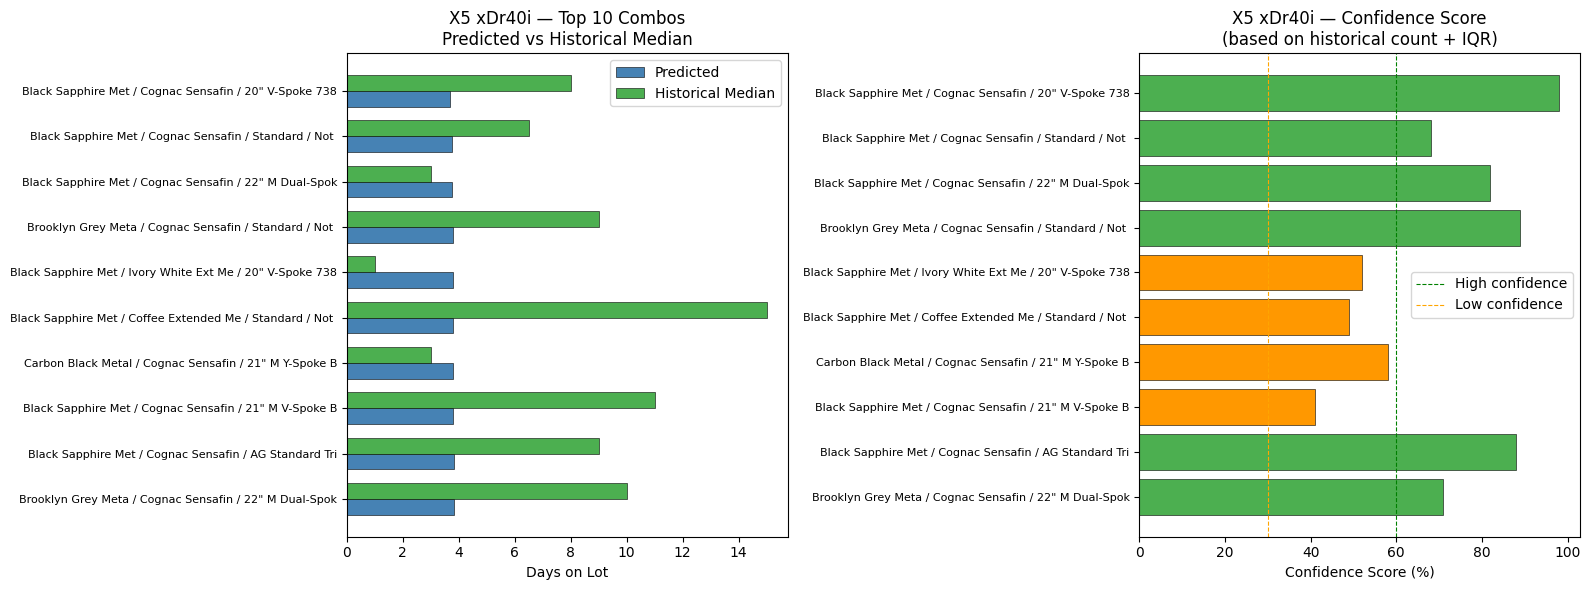

In [19]:
# Visual: top combos for X5 xDr40i (largest model by volume)
model_viz = 'X5 xDr40i'
if model_viz in combo_cache:
    top10 = pd.DataFrame(combo_cache[model_viz][:10])
    top10['label'] = (top10['color_name'].str[:18] + ' / ' +
                      top10['upholstery_name'].str[:18] + ' / ' +
                      top10['wheel_name'].str[:15])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Predicted vs Historical
    x = np.arange(len(top10))
    w = 0.35
    axes[0].barh(x + w/2, top10['predicted_days'], w, color='steelblue', label='Predicted', edgecolor='black', lw=0.4)
    axes[0].barh(x - w/2, top10['hist_median'],    w, color='#4CAF50',   label='Historical Median', edgecolor='black', lw=0.4)
    axes[0].set_yticks(x); axes[0].set_yticklabels(top10['label'], fontsize=8)
    axes[0].set_xlabel('Days on Lot'); axes[0].invert_yaxis()
    axes[0].set_title(f'{model_viz} — Top 10 Combos\nPredicted vs Historical Median')
    axes[0].legend()

    # Confidence
    conf_colors = ['#4CAF50' if c >= 60 else '#FF9800' if c >= 30 else '#f44336' for c in top10['confidence']]
    axes[1].barh(x, top10['confidence'], color=conf_colors, edgecolor='black', lw=0.4)
    axes[1].set_yticks(x); axes[1].set_yticklabels(top10['label'], fontsize=8)
    axes[1].set_xlabel('Confidence Score (%)'); axes[1].invert_yaxis()
    axes[1].axvline(60, color='green',  linestyle='--', lw=0.8, label='High confidence')
    axes[1].axvline(30, color='orange', linestyle='--', lw=0.8, label='Low confidence')
    axes[1].set_title(f'{model_viz} — Confidence Score\n(based on historical count + IQR)')
    axes[1].legend()

    plt.tight_layout(); plt.show()

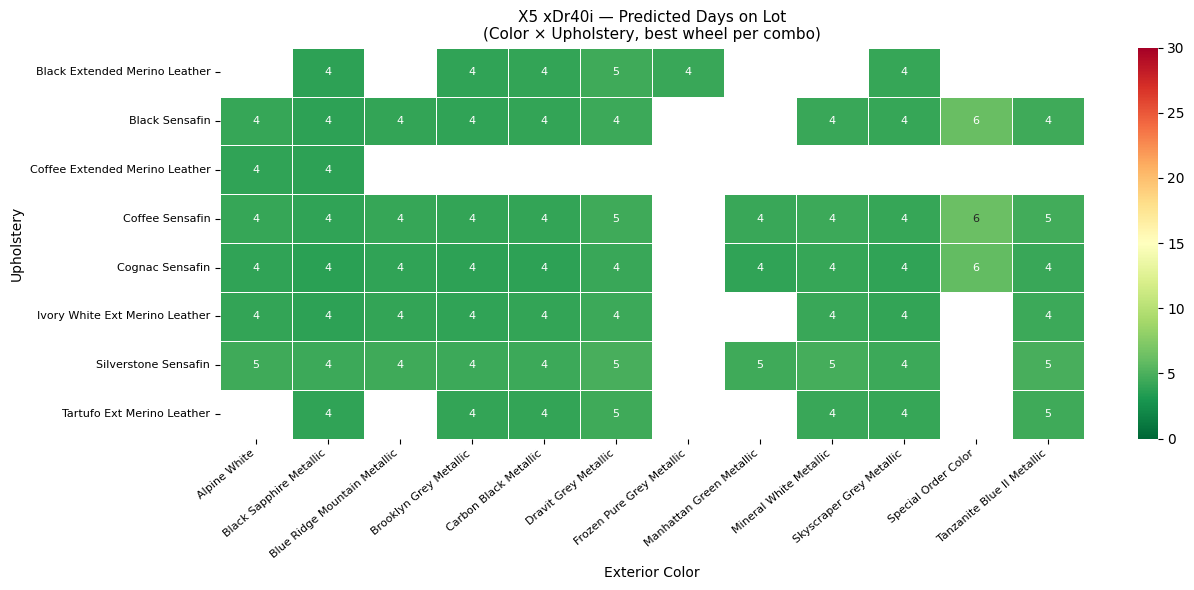

In [20]:
# Heatmap: color x upholstery median predicted days (for the top model, best wheel per combo)
model_viz = 'X5 xDr40i'
if model_viz in combo_cache:
    combos_df = pd.DataFrame(combo_cache[model_viz])
    # Best (lowest predicted) wheel for each (color, upholstery) pair
    best = combos_df.sort_values('predicted_days').drop_duplicates(['color_code','upholstery_code'])
    pivot = best.pivot(index='upholstery_name', columns='color_name', values='predicted_days')

    fig, ax = plt.subplots(figsize=(max(10, pivot.shape[1]*1.1), max(6, pivot.shape[0]*0.6)))
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r', ax=ax,
                linewidths=0.4, annot_kws={'size': 8}, vmin=0, vmax=30)
    ax.set_title(f'{model_viz} — Predicted Days on Lot\n(Color × Upholstery, best wheel per combo)', fontsize=11)
    ax.set_xlabel('Exterior Color'); ax.set_ylabel('Upholstery')
    plt.xticks(rotation=40, ha='right', fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout(); plt.show()

## 8. Save Model Artifacts

In [21]:
import torch

# Save LightGBM model
lgbm_model.save_model(MODELS_DIR + 'lgbm_p34.txt')
print(f'Saved: {MODELS_DIR}lgbm_p34.txt')

# Save Ridge model + scaler
with open(MODELS_DIR + 'ridge_p34.pkl', 'wb') as f:
    pickle.dump({'model': ridge_model, 'scaler': scaler_ridge}, f)
print(f'Saved: {MODELS_DIR}ridge_p34.pkl')

# Save Neural Network model + scaler
torch.save({'model_state': nn_model.state_dict(), 'in_dim': X_train.shape[1]}, MODELS_DIR + 'nn_p34.pkl')
with open(MODELS_DIR + 'nn_scaler_p34.pkl', 'wb') as f:
    pickle.dump(scaler_nn, f)
print(f'Saved: {MODELS_DIR}nn_p34.pkl  +  nn_scaler_p34.pkl')

# Save Optuna TabularMLP + scaler
torch.save({'model_state': optuna_model.state_dict(),
            'best_params': best_params,
            'in_dim': X_train.shape[1]}, MODELS_DIR + 'optuna_mlp_p34.pkl')
with open(MODELS_DIR + 'optuna_scaler_p34.pkl', 'wb') as f:
    pickle.dump(scaler_opt, f)
print(f'Saved: {MODELS_DIR}optuna_mlp_p34.pkl  +  optuna_scaler_p34.pkl')

# Save feature columns (exact order for inference alignment)
with open(MODELS_DIR + 'feature_columns.pkl', 'wb') as f:
    pickle.dump(FEATURE_COLS, f)
print(f'Saved: {MODELS_DIR}feature_columns.pkl  ({len(FEATURE_COLS)} features)')

# Save median fills (for imputation at inference)
with open(MODELS_DIR + 'median_fills.pkl', 'wb') as f:
    pickle.dump(MEDIAN_FILLS, f)
print(f'Saved: {MODELS_DIR}median_fills.pkl')

# Save combo cache (pre-scored recommendations per model)
with open(MODELS_DIR + 'combo_cache.pkl', 'wb') as f:
    pickle.dump(combo_cache, f)
print(f'Saved: {MODELS_DIR}combo_cache.pkl')

# Save lookup maps + best model info
meta = {
    'color_map':        color_map,
    'uph_map':          uph_map,
    'wheel_map':        wheel_map,
    'pkg_cols':         PKG_COLS,
    'wheel_codes':      WHEEL_CODES,
    'BEST_MODEL_NAME':  BEST_MODEL_NAME,
    'best_model_mae':   best_model_mae,
}
with open(MODELS_DIR + 'meta.pkl', 'wb') as f:
    pickle.dump(meta, f)
print(f'Saved: {MODELS_DIR}meta.pkl  (best_model={BEST_MODEL_NAME}, mae={best_model_mae:.3f})')

print('\nAll artifacts saved to', MODELS_DIR)


Saved: /content/optimizer_models/lgbm_p34.txt
Saved: /content/optimizer_models/ridge_p34.pkl
Saved: /content/optimizer_models/nn_p34.pkl  +  nn_scaler_p34.pkl
Saved: /content/optimizer_models/optuna_mlp_p34.pkl  +  optuna_scaler_p34.pkl
Saved: /content/optimizer_models/feature_columns.pkl  (256 features)
Saved: /content/optimizer_models/median_fills.pkl
Saved: /content/optimizer_models/combo_cache.pkl
Saved: /content/optimizer_models/meta.pkl  (best_model=LightGBM, mae=7.528)

All artifacts saved to /content/optimizer_models/


## 9. Explainability — Why Does This Combo Sell Faster?

SHAP force plots on the fastest vs. slowest recommendation for the top model.

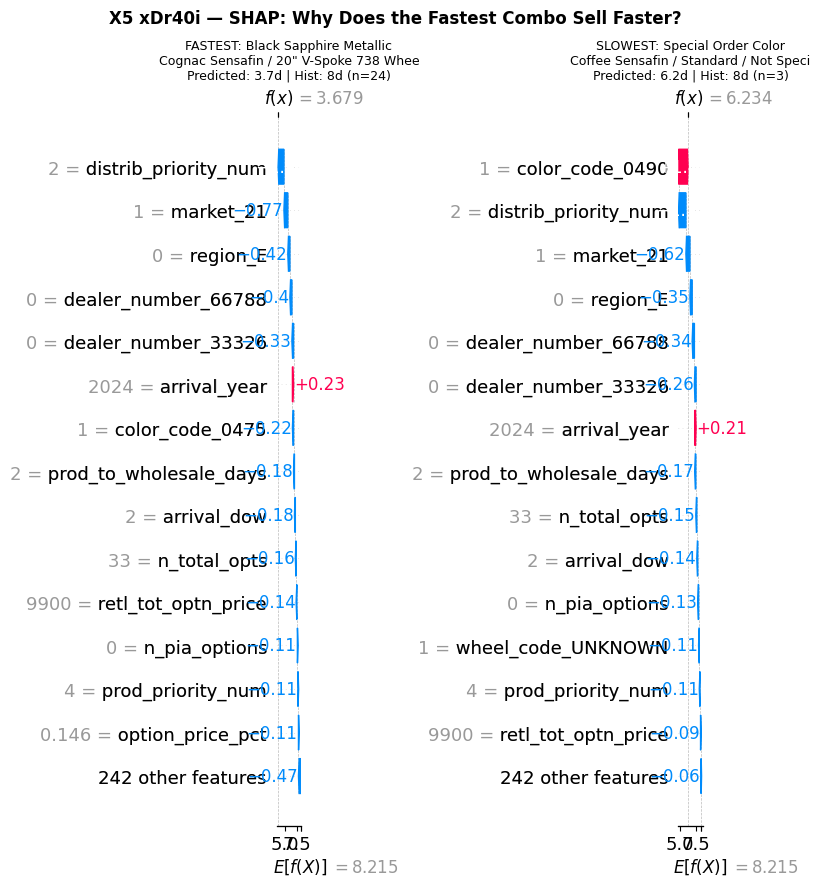

In [22]:
model_viz = 'X5 xDr40i'
if model_viz in combo_cache:
    combos = combo_cache[model_viz]
    fastest = combos[0]   # lowest predicted days
    slowest = combos[-1]  # highest predicted days

    def make_synth_df(combo_dict):
        model_idx = df[df['short_description'] == model_viz].index
        med_row   = X.loc[model_idx].median()
        synth = build_synthetic_row(med_row, combo_dict['color_code'],
                                    combo_dict['upholstery_code'], combo_dict['wheel_code'])
        return pd.DataFrame([synth], columns=FEATURE_COLS)

    X_fast = make_synth_df(fastest)
    X_slow = make_synth_df(slowest)
    X_compare = pd.concat([X_fast, X_slow], ignore_index=True)

    shap_compare = explainer(X_compare)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    plt.sca(axes[0])
    shap.plots.waterfall(shap_compare[0], max_display=15, show=False)
    axes[0].set_title(
        f'FASTEST: {fastest["color_name"][:25]}\n'
        f'{fastest["upholstery_name"][:25]} / {fastest["wheel_name"][:20]}\n'
        f'Predicted: {fastest["predicted_days"]:.1f}d | Hist: {fastest["hist_median"]:.0f}d (n={fastest["hist_count"]})',
        fontsize=9
    )

    plt.sca(axes[1])
    shap.plots.waterfall(shap_compare[1], max_display=15, show=False)
    axes[1].set_title(
        f'SLOWEST: {slowest["color_name"][:25]}\n'
        f'{slowest["upholstery_name"][:25]} / {slowest["wheel_name"][:20]}\n'
        f'Predicted: {slowest["predicted_days"]:.1f}d | Hist: {slowest["hist_median"]:.0f}d (n={slowest["hist_count"]})',
        fontsize=9
    )

    plt.suptitle(f'{model_viz} — SHAP: Why Does the Fastest Combo Sell Faster?',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

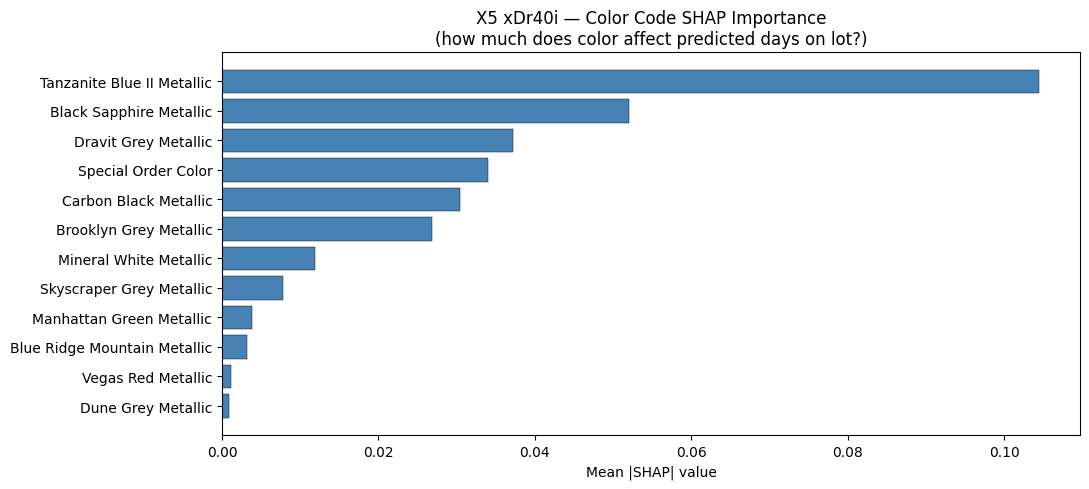

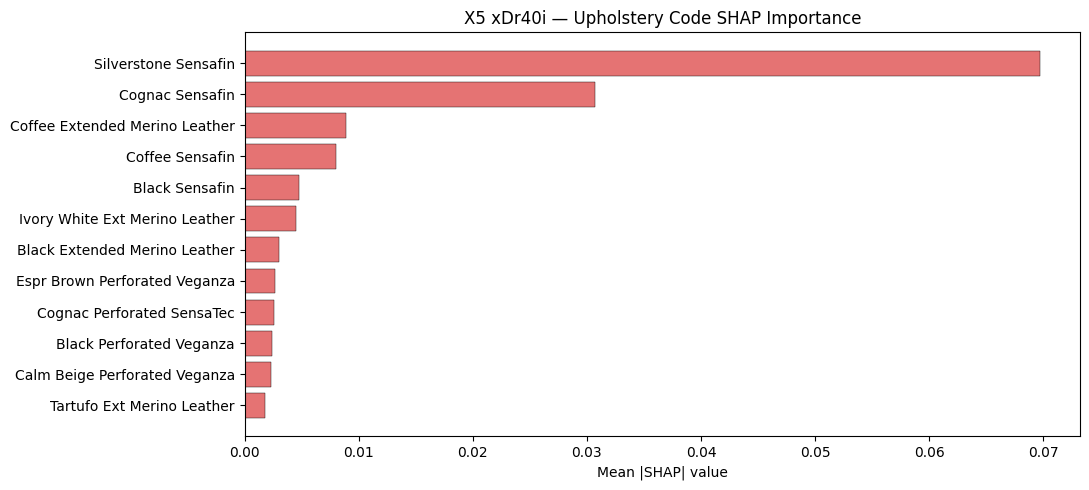

In [23]:
# SHAP dependence: color vs predicted days for X5 xDr40i
model_viz = 'X5 xDr40i'
df_model_viz = df[df['short_description'] == model_viz].copy()
X_model_viz  = X.loc[df_model_viz.index]
shap_model   = explainer(X_model_viz)

# Find top color OHE columns by SHAP importance
shap_df_model = pd.DataFrame(shap_model.values, columns=FEATURE_COLS)
color_shap_cols = [c for c in FEATURE_COLS if c.startswith('color_code_')]
color_importance = shap_df_model[color_shap_cols].abs().mean().sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(11, 5))
color_names = [color_map.get(c.replace('color_code_',''), c.replace('color_code_','')) for c in color_importance.index]
bars = ax.barh(color_names, color_importance.values, color='steelblue', edgecolor='black', lw=0.3)
ax.set_xlabel('Mean |SHAP| value')
ax.set_title(f'{model_viz} — Color Code SHAP Importance\n(how much does color affect predicted days on lot?)')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

# Same for upholstery
uph_shap_cols = [c for c in FEATURE_COLS if c.startswith('upholstery_code_')]
uph_importance = shap_df_model[uph_shap_cols].abs().mean().sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(11, 5))
uph_names = [uph_map.get(c.replace('upholstery_code_',''), c.replace('upholstery_code_','')) for c in uph_importance.index]
ax.barh(uph_names, uph_importance.values, color='#E57373', edgecolor='black', lw=0.3)
ax.set_xlabel('Mean |SHAP| value')
ax.set_title(f'{model_viz} — Upholstery Code SHAP Importance')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 10. Summary

| Item | Value |
|---|---|
| Training data | Priority 3 & 4 customer orders only |
| Priority 1 | Excluded — pre-committed, spec-independent |
| Target | `days_on_lot` capped at 90 days |
| Optimizer levers | `color_code`, `upholstery_code`, `wheel_code` |
| Scoring method | Counterfactual: median vehicle row, vary only spec |
| Saved artifacts | `lgbm_p34.txt`, `combo_cache.pkl`, `feature_columns.pkl`, `median_fills.pkl`, `meta.pkl` |

### How the recommendations work
For each model (e.g. X5 xDr40i), the optimizer:
1. Finds all (color, upholstery, wheel) combos that have appeared at least 3 times in historical P3/4 data
2. Scores each combo by predicting days-on-lot for a representative vehicle of that model
3. Ranks by predicted days (ascending = fastest first)
4. Reports historical median, count, confidence, and days distribution alongside the prediction

### Confidence score
- **60 pts** from historical count (scales up to 15 vehicles)
- **40 pts** from IQR tightness (lower spread = more consistent = higher confidence)
- High confidence (≥60): reliable recommendation backed by solid data
- Low confidence (<30): model prediction only, limited historical backing — treat as directional